# Tuning


In [1]:
import json
from pathlib import Path

from catboost import CatBoostClassifier
import joblib
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/validation.parquet")

target = "is_canceled"

drop_cols = [
    target,
    "booking_date",
    "arrival_date"
]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]


In [2]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

for col in categorical_cols:
    X_train[col] = (
        X_train[col]
        .astype("object")
        .where(X_train[col].notna(), np.nan)
    )

    X_val[col] = (
        X_val[col]
        .astype("object")
        .where(X_val[col].notna(), np.nan)
    )


In [3]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [4]:
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)

print(X_train_enc.shape)
print(X_val_enc.shape)

(82629, 801)
(18065, 801)


## LightGBM
Гиперпараметры подберем с помощью `Random search`


In [5]:
param_grid = {
    "num_leaves": [15, 31, 63, 95],
    "max_depth": [-1, 6, 8, 10],
    "min_child_samples": [20, 50, 100, 200],
    "learning_rate": [0.02, 0.05, 0.08],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0, 5.0]
}

In [6]:
params_list = list(
    ParameterSampler(
        param_grid,
        n_iter=25,
        random_state=42
    )
)

len(params_list)


25

In [7]:
tuning_results = []

for i, params in enumerate(params_list, start=1):

    # Не используем слишком много leaves заранее
    # при ограниченной глубине
    if (
        params["max_depth"] > 0
        and params["num_leaves"] > 2 ** params["max_depth"]
    ):
        continue

    model = LGBMClassifier(
        n_estimators=3000,
        objective="binary",
        subsample_freq=1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **params
    )

    model.fit(
        X_train_enc,
        y_train,
        eval_set=[(X_val_enc, y_val)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(
                100,
                verbose=False
            )
        ]
    )

    proba = model.predict_proba(X_val_enc)[:, 1]

    tuning_results.append({
        **params,
        "best_iteration": model.best_iteration_,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba)
    })

    print(
        f"{i}/{len(params_list)} | "
        f"ROC-AUC: {tuning_results[-1]['roc_auc']:.4f} | "
        f"PR-AUC: {tuning_results[-1]['pr_auc']:.4f}"
    )


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


1/25 | ROC-AUC: 0.9248 | PR-AUC: 0.8983


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


2/25 | ROC-AUC: 0.9231 | PR-AUC: 0.8959


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


3/25 | ROC-AUC: 0.9227 | PR-AUC: 0.8956


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


4/25 | ROC-AUC: 0.9239 | PR-AUC: 0.8969


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


5/25 | ROC-AUC: 0.9225 | PR-AUC: 0.8950


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


6/25 | ROC-AUC: 0.9225 | PR-AUC: 0.8958


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


7/25 | ROC-AUC: 0.9242 | PR-AUC: 0.8977


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


8/25 | ROC-AUC: 0.9220 | PR-AUC: 0.8949


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


9/25 | ROC-AUC: 0.9227 | PR-AUC: 0.8958


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


10/25 | ROC-AUC: 0.9237 | PR-AUC: 0.8969


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


11/25 | ROC-AUC: 0.9228 | PR-AUC: 0.8954


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


12/25 | ROC-AUC: 0.9231 | PR-AUC: 0.8960


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


13/25 | ROC-AUC: 0.9240 | PR-AUC: 0.8970


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


14/25 | ROC-AUC: 0.9219 | PR-AUC: 0.8946


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


15/25 | ROC-AUC: 0.9238 | PR-AUC: 0.8972


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


16/25 | ROC-AUC: 0.9243 | PR-AUC: 0.8976


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


17/25 | ROC-AUC: 0.9226 | PR-AUC: 0.8954


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


18/25 | ROC-AUC: 0.9225 | PR-AUC: 0.8954


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


19/25 | ROC-AUC: 0.9243 | PR-AUC: 0.8978


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


20/25 | ROC-AUC: 0.9229 | PR-AUC: 0.8964


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


21/25 | ROC-AUC: 0.9255 | PR-AUC: 0.8987


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


22/25 | ROC-AUC: 0.9220 | PR-AUC: 0.8947


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


24/25 | ROC-AUC: 0.9233 | PR-AUC: 0.8962


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


25/25 | ROC-AUC: 0.9233 | PR-AUC: 0.8965


In [8]:
tuning_df = (
    pd.DataFrame(tuning_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

tuning_df.head(10)

,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_depth,learning_rate,colsample_bytree,best_iteration,roc_auc,pr_auc
0,0.70,1.0,0.0,95,20,-1,0.02,0.70,469,0.925546,0.898715
1,0.70,0.0,0.1,95,50,-1,0.05,0.85,175,0.924823,0.898261
2,1.00,1.0,0.0,95,20,10,0.05,0.85,263,0.924281,0.897800
3,0.70,0.1,0.0,95,100,-1,0.05,0.85,187,0.924191,0.897653
4,0.70,0.0,0.0,63,100,-1,0.05,1.00,223,0.924301,0.897583
5,0.70,0.5,0.5,63,100,8,0.05,0.70,406,0.923775,0.897171
6,1.00,5.0,0.1,31,100,-1,0.08,0.85,148,0.923995,0.896955
7,0.85,1.0,0.1,15,100,8,0.05,0.70,608,0.923906,0.896885
8,0.70,0.1,0.5,15,100,8,0.02,0.70,1288,0.923686,0.896870
9,0.70,0.5,1.0,31,200,-1,0.08,1.00,171,0.923271,0.896474


После tuning `LightGBM` получил `ROC-AUC` = 0.92 и `PR-AUC` = 0.899. По сравнению с базовой версией качество немного выросло, но сильного прироста нет. Дальше нужно проверить, даст ли tuning `CatBoost` больше.


## CatBoost


In [13]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

cat_features = X_train_cb.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype("string").fillna("Missing")
    X_val_cb[col] = X_val_cb[col].astype("string").fillna("Missing")

In [14]:
cat_param_grid = {
    "depth": [5, 6, 7, 8, 9],
    "learning_rate": [0.02, 0.04, 0.06, 0.08],
    "l2_leaf_reg": [1, 3, 5, 10, 20],
    "random_strength": [0, 0.5, 1, 2],
    "bagging_temperature": [0, 0.5, 1, 2, 5]
}

In [15]:
cat_params_list = list(
    ParameterSampler(
        cat_param_grid,
        n_iter=15,
        random_state=42
    )
)


In [16]:
cat_tuning_results = []

for i, params in enumerate(cat_params_list, start=1):

    model = CatBoostClassifier(
        iterations=2000,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        **params
    )

    model.fit(
        X_train_cb,
        y_train,
        cat_features=cat_features,
        eval_set=(X_val_cb, y_val),
        early_stopping_rounds=100,
        use_best_model=True
    )

    proba = model.predict_proba(X_val_cb)[:, 1]

    cat_tuning_results.append({
        **params,
        "best_iteration": model.best_iteration_,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba)
    })

    print(
        f"{i}/{len(cat_params_list)} | "
        f"ROC-AUC: {cat_tuning_results[-1]['roc_auc']:.4f} | "
        f"PR-AUC: {cat_tuning_results[-1]['pr_auc']:.4f}"
    )


1/15 | ROC-AUC: 0.9248 | PR-AUC: 0.8988
2/15 | ROC-AUC: 0.9251 | PR-AUC: 0.8990
3/15 | ROC-AUC: 0.9248 | PR-AUC: 0.8979
4/15 | ROC-AUC: 0.9247 | PR-AUC: 0.8982
5/15 | ROC-AUC: 0.9246 | PR-AUC: 0.8985
6/15 | ROC-AUC: 0.9252 | PR-AUC: 0.8989
7/15 | ROC-AUC: 0.9245 | PR-AUC: 0.8977
8/15 | ROC-AUC: 0.9253 | PR-AUC: 0.8996
9/15 | ROC-AUC: 0.9245 | PR-AUC: 0.8979
10/15 | ROC-AUC: 0.9255 | PR-AUC: 0.8993
11/15 | ROC-AUC: 0.9240 | PR-AUC: 0.8968
12/15 | ROC-AUC: 0.9245 | PR-AUC: 0.8979
13/15 | ROC-AUC: 0.9246 | PR-AUC: 0.8985
14/15 | ROC-AUC: 0.9251 | PR-AUC: 0.8984
15/15 | ROC-AUC: 0.9251 | PR-AUC: 0.8985


In [17]:
cat_tuning_df = (
    pd.DataFrame(cat_tuning_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

cat_tuning_df.head(10)

,random_strength,learning_rate,l2_leaf_reg,depth,bagging_temperature,best_iteration,roc_auc,pr_auc
0,0.0,0.04,1,8,1.0,435,0.925298,0.899558
1,0.5,0.06,5,6,0.0,612,0.925473,0.899271
2,2.0,0.02,3,8,2.0,906,0.925052,0.899003
3,2.0,0.04,10,8,1.0,424,0.925164,0.898889
4,1.0,0.04,1,9,1.0,484,0.924841,0.898814
5,1.0,0.06,1,9,1.0,179,0.924637,0.898533
6,1.0,0.06,1,9,0.0,179,0.924637,0.898533
7,2.0,0.04,1,6,0.0,997,0.925058,0.898529
8,1.0,0.06,5,8,2.0,280,0.925081,0.898403
9,1.0,0.08,1,6,2.0,586,0.924711,0.898237


## Вывод
После tuning лучший результат показал `LightGBM`: `ROC-AUC` = 0.9254, `PR-AUC` = 0.8990. Лучший `CatBoost` получил `ROC-AUC` = 0.9237, `PR-AUC` = 0.8974.

Разница небольшая, но `LightGBM` одновременно показывает лучшее качество на validation и значительно быстрее обучается в текущем окружении, ну и `CatBoost` уже надоел. Поэтому дальше выбираю `LightGBM` как основного кандидата на финальную модель.


## Найдем порог


In [9]:
best_lgb_params = {
    "subsample": 0.70,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "num_leaves": 95,
    "min_child_samples": 20,
    "max_depth": -1,
    "learning_rate": 0.02,
    "colsample_bytree": 0.70
}

best_iteration = 399

In [10]:
best_lgb_model = LGBMClassifier(
    n_estimators=399,
    learning_rate=0.02,
    num_leaves=95,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.70,
    subsample_freq=1,
    colsample_bytree=0.70,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

best_lgb_model.fit(
    X_train_enc,
    y_train
)

,num_leaves,95
,learning_rate,0.02
,n_estimators,399
,objective,'binary'
,subsample,0.7
,subsample_freq,1
,colsample_bytree,0.7
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,verbosity,-1


Получаем вероятности


In [11]:
val_proba = best_lgb_model.predict_proba(X_val_enc)[:, 1]

Делаем табличку с порогами и метриками


In [12]:
threshold_results = []

for threshold in np.arange(0.10, 0.81, 0.05):
    pred = (val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "fp": fp,
        "fn": fn,
        "predicted_cancellations": pred.sum(),
        "predicted_share": pred.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)


,threshold,precision,recall,f1,fp,fn,predicted_cancellations,predicted_share
0,0.10,0.567,0.988,0.721,5348,83,12361,0.684
1,0.15,0.600,0.978,0.744,4623,158,11561,0.640
2,0.20,0.626,0.965,0.759,4091,249,10938,0.605
3,0.25,0.646,0.952,0.770,3693,343,10446,0.578
4,0.30,0.666,0.935,0.778,3327,460,9963,0.552
5,0.35,0.694,0.917,0.790,2868,587,9377,0.519
6,0.40,0.717,0.888,0.794,2486,793,8789,0.487
7,0.45,0.743,0.860,0.797,2110,994,8212,0.455
8,0.50,0.775,0.822,0.798,1692,1265,7523,0.416
9,0.55,0.800,0.786,0.793,1393,1522,6967,0.386


Визуализируем для удобства


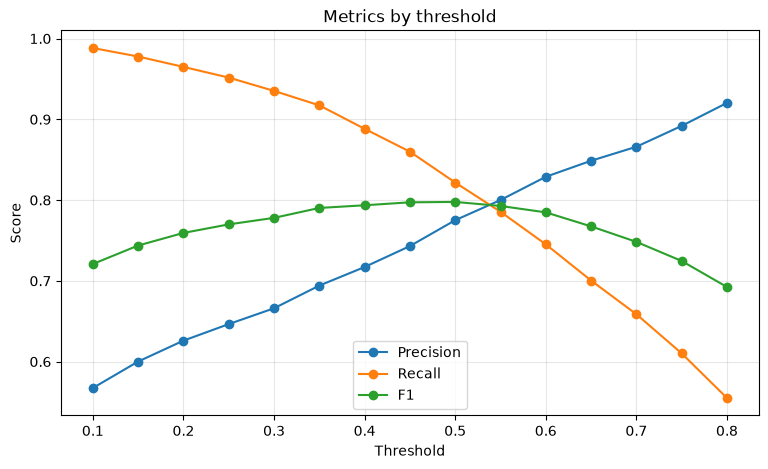

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics by threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [14]:
threshold_df.loc[
    threshold_df["f1"].idxmax()
]

threshold                     0.500000
precision                     0.775090
recall                        0.821731
f1                            0.797729
fp                         1692.000000
fn                         1265.000000
predicted_cancellations    7523.000000
predicted_share               0.416441
Name: 8, dtype: float64

In [15]:
candidates = threshold_df[
    threshold_df["recall"] >= 0.90
]

best_business_threshold = candidates.loc[
    candidates["precision"].idxmax()
]

best_business_threshold

threshold                     0.350000
precision                     0.694145
recall                        0.917277
f1                            0.790263
fp                         2868.000000
fn                          587.000000
predicted_cancellations    9377.000000
predicted_share               0.519070
Name: 5, dtype: float64

Подберем `threshold` более точно, используя `PR` кривую:


In [16]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_proba
)

threshold_search = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

candidates = threshold_search[
    threshold_search["recall"] >= 0.90
]

best_threshold_row = candidates.loc[
    candidates["precision"].idxmax()
]

best_threshold_row


threshold    0.382815
precision    0.709907
recall       0.900789
Name: 7493, dtype: float64

Метрики для найденного порога:


In [17]:
best_threshold = best_threshold_row["threshold"]

val_pred_final = (
    val_proba >= best_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_pred_final
).ravel()

final_threshold_results = {
    "threshold": best_threshold,
    "precision": best_threshold_row["precision"],
    "recall": best_threshold_row["recall"],
    "f1": f1_score(y_val, val_pred_final),
    "fp": fp,
    "fn": fn,
    "tp": tp,
    "tn": tn
}

final_threshold_results


{'threshold': np.float64(0.3828149414598991),
 'precision': np.float64(0.7099067081297201),
 'recall': np.float64(0.9007891770011274),
 'f1': 0.7940372670807453,
 'fp': np.int64(2612),
 'fn': np.int64(704),
 'tp': np.int64(6392),
 'tn': np.int64(8357)}

In [18]:
FINAL_THRESHOLD = float(best_threshold)

FINAL_THRESHOLD

0.3828149414598991

## Вывод
Стандартный `threshold` = 0.5 даёт максимальный `F1` = 0.799, но `Recall` составляет только 0.831. Для нашей задачи важнее не пропускать потенциальные отмены, поэтому использую `бизнес-критерий`: модель должна находить минимум 90% будущих отмен.

Среди порогов с Recall > 90% подбираю такой, где precision наибольший: threshold = 0.386


In [19]:
Path("../models").mkdir(parents=True, exist_ok=True)

joblib.dump(
    preprocessor,
    "../models/preprocessor.joblib"
)

joblib.dump(
    best_lgb_model,
    "../models/lightgbm_candidate.joblib"
)

metadata = {
    "threshold": float(FINAL_THRESHOLD),
    "categorical_cols": categorical_cols,
    "drop_cols": [
        "is_canceled",
        "booking_date",
        "arrival_date"
    ],
    "model": "LightGBM"
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)
